In [ ]:
all_paths = []

for row in df.itertuples(index=False):
    target_id = row.id
    query_text = row.Description
    real_path = row.Path
    
    all_paths.append(real_path)

    embedding = encoder.encode(query_text)
    results = db.search(embedding, len(df))

    rows = output_processor.create_dict_of_rows(results)

    processed_rows = []

    for rank, r in enumerate(rows):
        path = r.get("path")
        name = str(Path(path).name)
        db_desc = r.get("text_description")
        score = r.get("score")

        file_id = id_map.get(Path(path).name)
        processed_rows.append([name, score])


    print(rows)

[{'path': 'testing/4.jpg', 'score': '0.7310386282771437', 'text_description': "This humorous photo features a close-up of a young Asian cat, likely with a tabby pattern, with white fur around its eyes and nose. The cat's striking greenish hues are accentuated with the lighting. The kitten’s eyes are notably wide open, giving it an excited or alert expression, reminiscent of a cat"}, {'path': 'testing/1.jpg', 'score': '0.7156862833286353', 'text_description': "The image is an extremely close-up photo of a cat, likely a Staffordshire Bull Terrier, characterized by its orange-brown fur with distinct white striping on its chest. The cat's head is the focal point, with a mix of brown and blonde fur. Its gaze appears intense and almost menacing, as if"}, {'path': 'testing/vid_7.MP4', 'score': '0.7113099493484966', 'text_description': 'In the image, a domesticated orange cat with dark stripes is prominently featured lying on a bed. The cat extends its front paws and ears forward, as its face 

In [ ]:
matrix_rows = []
row_names = []

for row in df.itertuples(index=False):
    target_id = row.id
    query_text = row.Description
    real_path = row.Path

    embedding = encoder.encode(query_text)
    results = db.search(embedding, len(df))

    rows = output_processor.create_dict_of_rows(results)

    processed_rows = []
    for r in rows:
        path = r["path"]
        name = Path(path).name
        score = float(r["score"])

        processed_rows.append([name, score])

    scores_df = pd.DataFrame(processed_rows, columns=["name", "score"])

    scores_df["type"] = scores_df["name"].str.startswith("vid_").map(
        {True: "video", False: "image"}
    )
    scores_df["index"] = scores_df["name"].str.extract(r"(\d+)").astype(int)

    scores_df = (
        scores_df.sort_values(
            by=["type", "index"],
            key=lambda s: s.map({"image": 0, "video": 1}) if s.name == "type" else s,
        )
        .reset_index(drop=True)
    )

    matrix_rows.append(scores_df.set_index("name")["score"])
    row_names.append(real_path)

score_df = pd.DataFrame(matrix_rows, index=row_names)
score_matrix = score_df.to_numpy()


In [ ]:
score_df

name,1.jpg,2.jpg,3.jpg,4.jpg,5.jpg,6.jpg,7.jpg,8.jpg,9.jpg,10.jpg,...,vid_11.mp4,vid_12.MP4,vid_13.mp4,vid_14.mp4,vid_15.mp4,vid_16.mp4,vid_17.mp4,vid_18.mp4,vid_19.mp4,vid_20.mp4
1.jpg,0.715686,0.512674,0.515991,0.731039,0.610029,0.621106,0.543422,0.483238,0.542664,0.548313,...,0.518895,0.666274,0.407282,0.558671,0.510130,0.514389,0.516132,0.555313,0.465757,0.514004
2.jpg,0.540441,0.716484,0.402075,0.512875,0.492447,0.504219,0.471501,0.406594,0.484334,0.440881,...,0.442027,0.617096,0.416352,0.388914,0.411462,0.433567,0.395430,0.434381,0.410629,0.426669
3.jpg,0.582388,0.507666,0.772782,0.580950,0.581754,0.559737,0.626499,0.570192,0.649336,0.588547,...,0.607823,0.631571,0.518030,0.576334,0.573281,0.561318,0.558714,0.650667,0.579320,0.567732
4.jpg,0.680973,0.526981,0.526124,0.727461,0.623570,0.646289,0.614440,0.500044,0.583071,0.568844,...,0.511790,0.676543,0.457203,0.601566,0.553987,0.543855,0.502084,0.583152,0.507395,0.495098
5.jpg,0.615191,0.539402,0.520298,0.536685,0.615501,0.592352,0.595582,0.536371,0.561428,0.527005,...,0.484457,0.617583,0.445084,0.512223,0.521426,0.512465,0.501580,0.593263,0.506595,0.524486
6.jpg,0.603111,0.457870,0.490308,0.652629,0.659509,0.700552,0.515273,0.449814,0.516787,0.463850,...,0.438019,0.578826,0.446430,0.579373,0.461536,0.512690,0.416968,0.574646,0.424527,0.450365
7.jpg,0.490422,0.427298,0.508199,0.477508,0.424251,0.475079,0.619606,0.457536,0.637216,0.610189,...,0.460420,0.514793,0.606408,0.557482,0.517890,0.509931,0.463314,0.576814,0.426651,0.430969
8.jpg,0.407537,0.463033,0.478721,0.456150,0.455220,0.421868,0.457825,0.756848,0.452186,0.516917,...,0.516567,0.432219,0.424526,0.465368,0.527867,0.468361,0.536801,0.529258,0.525906,0.486922
9.jpg,0.451193,0.381008,0.542258,0.499478,0.473844,0.486676,0.583262,0.572673,0.548102,0.572903,...,0.499466,0.470304,0.508426,0.644301,0.510186,0.517115,0.495089,0.595661,0.557858,0.519929
10.jpg,0.461091,0.415865,0.494865,0.482691,0.478584,0.469602,0.518780,0.596216,0.550024,0.548973,...,0.491624,0.435981,0.446563,0.523619,0.518432,0.519786,0.475817,0.553689,0.486377,0.496180


<Axes: >

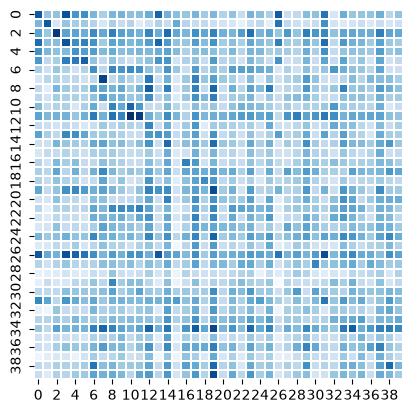

In [ ]:
sns.heatmap(
        score_matrix,
        cmap="Blues",
        square=True,
        cbar=False,
        linewidths=0.2,
    )